## 1. Instalar las bibliotecas

MediaPipe ejecuta el modelo de vision artificial y OpenCV permite leer y dibujar sobre la imagen.

In [1]:
!pip install -q mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.3 MB/s eta 0:00:00


## 2. Importar las herramientas

Importar significa hacer disponibles las funciones de las bibliotecas dentro del cuaderno.

In [2]:
from pathlib import Path
import urllib.request

import cv2
import mediapipe as mp
import numpy as np

from google.colab import files
from google.colab.patches import cv2_imshow

print('Entorno listo: Google Colab')

Entorno listo: Google Colab


## 3. Descargar el modelo preentrenado

In [3]:
MODELO_URL = (
    'https://storage.googleapis.com/mediapipe-models/object_detector/'
    'efficientdet_lite0/float32/1/efficientdet_lite0.tflite'
)
MODELO_RUTA = Path('efficientdet_lite0.tflite')

if not MODELO_RUTA.exists():
    print('Descargando el modelo...')
    urllib.request.urlretrieve(MODELO_URL, MODELO_RUTA)

print('Modelo listo:', MODELO_RUTA)

Descargando el modelo...
Modelo listo: efficientdet_lite0.tflite


## 4. Configurar el detector

In [7]:
opciones = mp.tasks.vision.ObjectDetectorOptions(
    base_options=mp.tasks.BaseOptions(
        model_asset_path=str(MODELO_RUTA.resolve())
    ),
    running_mode=mp.tasks.vision.RunningMode.IMAGE,
    score_threshold=0.3,
    max_results=5,
)

detector = mp.tasks.vision.ObjectDetector.create_from_options(opciones)
print('Detector listo')

Detector listo


## 5. Funciones para detectar y dibujar

In [5]:

def leer_imagen(ruta):
    datos = np.fromfile(ruta, dtype=np.uint8)
    imagen = cv2.imdecode(datos, cv2.IMREAD_COLOR)
    if imagen is None:
        raise ValueError('No se pudo leer la imagen seleccionada')
    return imagen

def detectar_y_dibujar(imagen_bgr):
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    imagen_mp = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=imagen_rgb,
    )
    resultado = detector.detect(imagen_mp)
    imagen_anotada = imagen_bgr.copy()

    for deteccion in resultado.detections:
        categoria = deteccion.categories[0]
        nombre = categoria.category_name or 'objeto'
        confianza = categoria.score
        caja = deteccion.bounding_box
        inicio = (caja.origin_x, caja.origin_y)
        fin = (
            caja.origin_x + caja.width,
            caja.origin_y + caja.height,
        )

        cv2.rectangle(imagen_anotada, inicio, fin, (40, 200, 40), 3)
        texto = f'{nombre}: {confianza:.0%}'
        texto_y = max(25, caja.origin_y - 10)
        cv2.putText(
            imagen_anotada, texto, (caja.origin_x, texto_y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (40, 200, 40), 2
        )
        print(f'- {nombre}: {confianza:.0%}')

    return imagen_anotada, resultado

## 6. Cargar y procesar una imagen

Saving WhatsApp Image 2026-08-22 at 20.06.02.jpeg to WhatsApp Image 2026-08-22 at 20.06.02.jpeg
Objetos detectados:
- person: 92%
- bowl: 54%


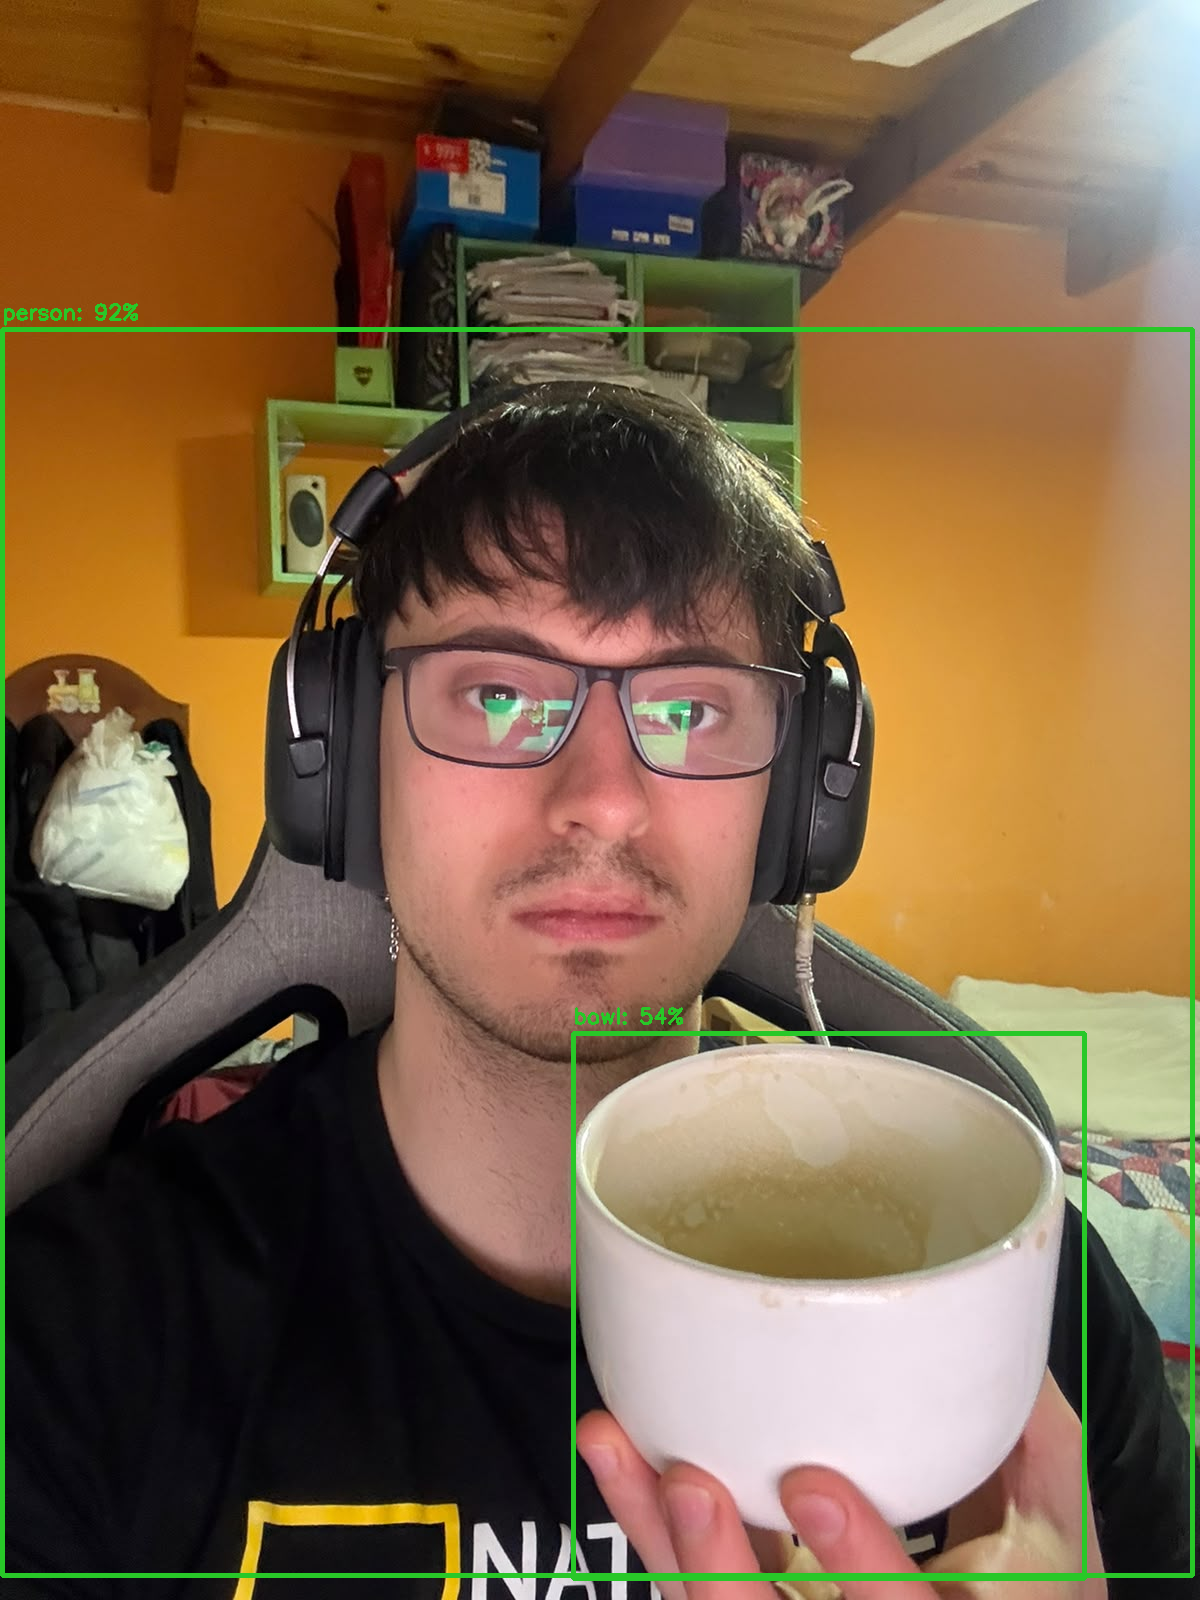

Resultado guardado en: resultado_deteccion.jpg


In [9]:
archivos = files.upload()
if not archivos:
    raise RuntimeError('No se selecciono ninguna imagen')
ruta_imagen = Path(next(iter(archivos)))

imagen = leer_imagen(ruta_imagen)
print('Objetos detectados:')
imagen_resultado, resultado = detectar_y_dibujar(imagen)

ruta_salida = 'resultado_deteccion.jpg'
cv2.imwrite(ruta_salida, imagen_resultado)
cv2_imshow(imagen_resultado)
print('Resultado guardado en:', ruta_salida)